<img src="/home/cyberpsychoz/NSU_studying-IIR/2_course/1_sem/PAC/images/Labs/IV/AE.png" alt="scheme" height=50% width=60%>

https://debuggercafe.com/implementing-deep-autoencoder-in-pytorch/

In [ ]:
class AutoEncoder(nn.Module):
    
    def __init__(self, img_shape, inp_dim, hidden_dim):
        super(AutoEncoder, self).__init__()
        self.img_shape = img_shape
        self.encoder = nn.Sequential(nn.Linear(inp_dim, 256),
                                     nn.ReLU(),
                                     nn.Linear(256, 128),
                                     nn.ReLU(),
                                     nn.Linear(128, hidden_dim)
                                    )
        self.decoder = nn.Sequential(nn.Linear(hidden_dim, 128),
                                     nn.ReLU(),
                                     nn.Linear(128, 256),
                                     nn.ReLU(),
                                     nn.Linear(256, inp_dim)
                                    )
    
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.encoder(x)
        x = self.decoder(x)
        return x.view(*self.img_shape)
    
    def encode(self, x):
        x = x.view(x.size(0), -1)
        return self.encoder(x)
    
    def decode(self. x_latent):
        return self.decoder(x).view(*self.img_shape)

### Train

<img src="/home/cyberpsychoz/NSU_studying-IIR/2_course/1_sem/PAC/images/Labs/IV/6.png" alt="scheme" height=50% width=60%>

In [ ]:
# constants
NUM_EPOCHS = 100
LEARNING_RATE = 1e-3
BATCH_SIZE = 128
# image transformations
transform = transforms.Compose([
    transforms.ToTensor(),
])

criterion = nn.MSELoss() # nn.BCELoss() 
optimizer = optim.Adam(net.parameters(), lr=LEARNING_RATE)

In [ ]:
# Dataset
trainset = datasets.FashionMNIST(
    root='./data',
    train=True, 
    download=False,
    transform=transform
)
testset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=False,
    transform=transform
)
# Dataloader
trainloader = DataLoader(
    trainset, 
    batch_size=BATCH_SIZE,
    shuffle=True
)
testloader = DataLoader(
    testset, 
    batch_size=BATCH_SIZE, 
    shuffle=True
)

In [ ]:
img.shape

In [ ]:
labeldict = {
    0: 'T-shirt/top',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot'
}

KERAS
https://www.kaggle.com/code/nathra/fashion-mnist-convolutional-autoencoder

In [ ]:
lat = model.encode(img[None,:,:,:])
res = model(img[None,:,:,:])

In [ ]:
print(lat.shape)
print(res.shape)

In [ ]:
plt.figure()
plt.plot(train_loss)
plt.title('Train Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.savefig('deep_ae_fashionmnist_loss.png')

#### save model!

In [ ]:
PATH = f'fashion_AE_{latent_space_dim}.pth'
torch.save(model.state_dict(), PATH)

In [ ]:
def display(img, img_size=28):
    """ Show image. """
    plt.imshow(img.numpy().reshape((img_size, img_size)), cmap='gray')
    plt.show()

In [ ]:
display(top[4])

In [ ]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox, TextArea
from sklearn.decomposition import PCA

In [ ]:
def plot_latent(x_test, count=1000):
    inputs, labels = next(iter(x_test))
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.set_title('autoencoder')
    encoded = model.encoder(inputs.to(device))
    coords = encoded.detach().cpu().numpy()
    #coords = PCA(n_components=2).fit_transform(encoded.reshape(count, -1))

    classes = labels.cpu().numpy() #[labeldict.get(label) for label in labels]
    plt.scatter(coords[:, 0], coords[:, 1], c=classes)
    plt.colorbar()
    for i in range(10):
        class_center = np.mean(coords[classes == i], axis=0)
        text = TextArea('{} ({})'.format(labeldict[i], i))
        ab = AnnotationBbox(text, class_center, xycoords='data', frameon=True)
        ax.add_artist(ab)
    plt.show()

In [ ]:
plot_latent(testloader)

### Test

In [ ]:
# load model
PATH = 'fashion_AE_4.pth'
model = AutoEncoder()
model.load_state_dict(torch.load(PATH))
model.eval()

In [ ]:
from ipywidgets import interactive

def plot(z1, z2, z3, z4):
    plt.figure(2)
    z = torch.Tensor([[z1, z2, z3, z4]]).to(device)
    decoded = decoder(z)
    img = decoded.reshape(28, 28).to('cpu').detach().numpy()
    plt.imshow(img, cmap='gray')
    plt.show()

interactive_plot = interactive(plot, z1=(0., 1., 0.01), z2=(0., 1., 0.01), z3=(0., 1., 0.01), z4=(0., 1., 0.01))
output = interactive_plot.children[-1]
output.layout.height = '350px'
interactive_plot

<img src="/home/cyberpsychoz/NSU_studying-IIR/2_course/1_sem/PAC/images/Labs/IV/ankle_boot.png" alt="scheme" height=30% width=40%>

### Denoising Auto Encoder

<img src="/home/cyberpsychoz/NSU_studying-IIR/2_course/1_sem/PAC/images/Labs/IV/13.png" alt="scheme" height=30% width=40%>

<img src="/home/cyberpsychoz/NSU_studying-IIR/2_course/1_sem/PAC/images/Labs/IV/14.png" alt="scheme" height=30% width=40%>

### Задания

Загрузка сведений…
1) Скачать Датасет FashionMNIST
2) Обучить полносвязный "АвтоЭнкодер"  (График тренировки + результаты работы (output img))
3) Обучить свёрточный "АвтоЭнкодер" (График тренировки + результаты работы (output img))
4) Визуализировать скрытое представление (интерактивный декодер)

5)* Обучить Вариационный Автокодировщик (VAE)
* + 1 балл к лабе

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interactive, FloatSlider
from IPython.display import display

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

In [2]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 784), 
            nn.ReLU(),
            nn.Linear(784, 256), 
            nn.ReLU(),
            nn.Linear(256, 128), 
            nn.ReLU(),
            nn.Linear(128, 64), 
            nn.ReLU(),
            nn.Linear(64, 2)
        )
        self.decoder = nn.Sequential(
            nn.Linear(2, 64), 
            nn.ReLU(),
            nn.Linear(64, 128), 
            nn.ReLU(),
            nn.Linear(128, 256), 
            nn.ReLU(),
            nn.Linear(256, 28 * 28), 
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        z = self.encoder(x)
        out = self.decoder(z)
        return out.view(-1, 1, 28, 28), z

def train_model(model, train_loader, test_loader, criterion, optimizer, epochs=10, scheduler=None):
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, _ in train_loader:
            images = images.to(device)

            optimizer.zero_grad()
            outputs, _ = model(images)
            loss = criterion(outputs, images)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, _ in test_loader:
                images = images.to(device)
                outputs, _ = model(images)
                loss = criterion(outputs, images)
                val_loss += loss.item()

        val_loss = val_loss / len(test_loader)
        val_losses.append(val_loss)

        if scheduler is not None:
            scheduler.step(val_loss)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    return train_losses, val_losses

model_fc = Autoencoder().to(device)
criterion = nn.BCELoss()
optimizer_fc = optim.Adam(model_fc.parameters(), lr=1e-3)

fc_train_loss, fc_val_loss = train_model(model_fc, train_loader, test_loader, criterion, optimizer_fc, epochs=15)

Epoch [1/15] | Train Loss: 0.4009 | Val Loss: 0.3396
Epoch [2/15] | Train Loss: 0.3335 | Val Loss: 0.3325
Epoch [3/15] | Train Loss: 0.3293 | Val Loss: 0.3300
Epoch [4/15] | Train Loss: 0.3269 | Val Loss: 0.3274
Epoch [5/15] | Train Loss: 0.3253 | Val Loss: 0.3256
Epoch [6/15] | Train Loss: 0.3240 | Val Loss: 0.3249
Epoch [7/15] | Train Loss: 0.3231 | Val Loss: 0.3247
Epoch [8/15] | Train Loss: 0.3225 | Val Loss: 0.3233
Epoch [9/15] | Train Loss: 0.3218 | Val Loss: 0.3229
Epoch [10/15] | Train Loss: 0.3208 | Val Loss: 0.3223
Epoch [11/15] | Train Loss: 0.3203 | Val Loss: 0.3218
Epoch [12/15] | Train Loss: 0.3200 | Val Loss: 0.3207
Epoch [13/15] | Train Loss: 0.3195 | Val Loss: 0.3206
Epoch [14/15] | Train Loss: 0.3188 | Val Loss: 0.3199
Epoch [15/15] | Train Loss: 0.3201 | Val Loss: 0.3211


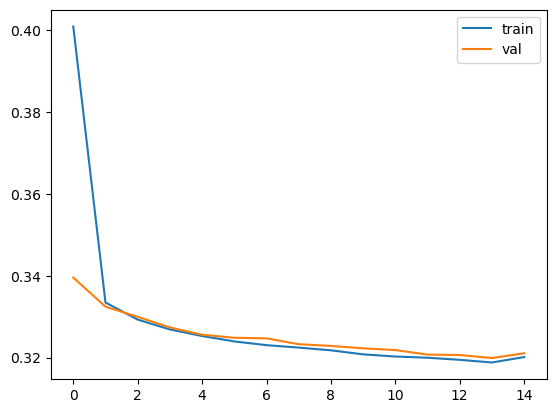

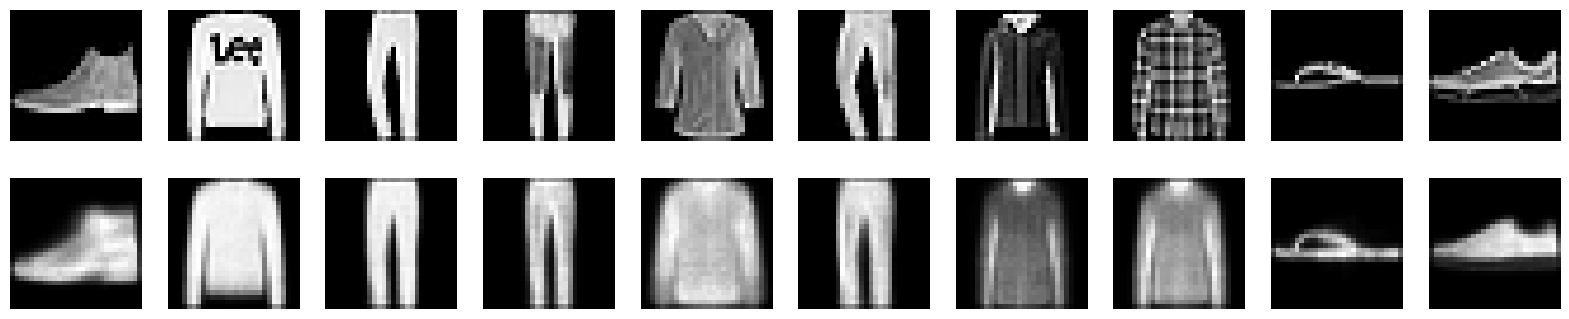

In [3]:
plt.plot(fc_train_loss, label='train')
plt.plot(fc_val_loss, label='val')
plt.legend()
plt.show()

def show_reconstructions(model, test_loader):
    model.eval()
    dataiter = iter(test_loader)
    images, _ = next(dataiter)
    images = images.to(device)

    with torch.no_grad():
        reconstructed, _ = model(images)

    images = images.cpu().numpy()
    reconstructed = reconstructed.cpu().numpy()

    plt.figure(figsize=(20, 4))
    for i in range(10):

        ax = plt.subplot(2, 10, i + 1)
        plt.imshow(images[i].squeeze(), cmap='gray')
        plt.axis("off")

        ax = plt.subplot(2, 10, i + 11)
        plt.imshow(reconstructed[i].squeeze(), cmap='gray')
        plt.axis("off")
    plt.show()

show_reconstructions(model_fc, test_loader)

In [4]:
class CNN_AE(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder
        self.enc_conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(2, 2), 

            nn.Conv2d(32, 16, kernel_size=3, padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.enc_fc = nn.Linear(16 * 7 * 7, 2) 

        # Decoder
        self.dec_fc = nn.Sequential(nn.Linear(2, 16 * 7 * 7), 
                                    nn.ReLU())
        self.dec_conv = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(16, 16, kernel_size=3, padding=1), 
            nn.ReLU(),

            nn.Upsample(scale_factor=2, mode='nearest'), 
            nn.Conv2d(16, 1, kernel_size=3, padding=1), 
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.enc_conv(x)
        x = x.view(-1, 16 * 7 * 7)
        z = self.enc_fc(x)

        out = self.dec_fc(z)
        out = out.view(-1, 16, 7, 7)
        out = self.dec_conv(out)
        return out, z

model_cnn = CNN_AE().to(device)
optimizer_cnn = optim.Adam(model_cnn.parameters(), lr=1e-3)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer_cnn, mode='min', factor=0.5, patience=3, min_lr=1e-7)

cnn_train_loss, cnn_val_loss = train_model(model_cnn, train_loader, test_loader, criterion, optimizer_cnn, epochs=15, scheduler=scheduler)

Epoch [1/15] | Train Loss: 0.4566 | Val Loss: 0.3757
Epoch [2/15] | Train Loss: 0.3650 | Val Loss: 0.3611
Epoch [3/15] | Train Loss: 0.3567 | Val Loss: 0.3565
Epoch [4/15] | Train Loss: 0.3532 | Val Loss: 0.3546
Epoch [5/15] | Train Loss: 0.3506 | Val Loss: 0.3513
Epoch [6/15] | Train Loss: 0.3489 | Val Loss: 0.3499
Epoch [7/15] | Train Loss: 0.3474 | Val Loss: 0.3485
Epoch [8/15] | Train Loss: 0.3461 | Val Loss: 0.3479
Epoch [9/15] | Train Loss: 0.3452 | Val Loss: 0.3464
Epoch [10/15] | Train Loss: 0.3441 | Val Loss: 0.3459
Epoch [11/15] | Train Loss: 0.3432 | Val Loss: 0.3450
Epoch [12/15] | Train Loss: 0.3426 | Val Loss: 0.3444
Epoch [13/15] | Train Loss: 0.3417 | Val Loss: 0.3441
Epoch [14/15] | Train Loss: 0.3412 | Val Loss: 0.3433
Epoch [15/15] | Train Loss: 0.3407 | Val Loss: 0.3425


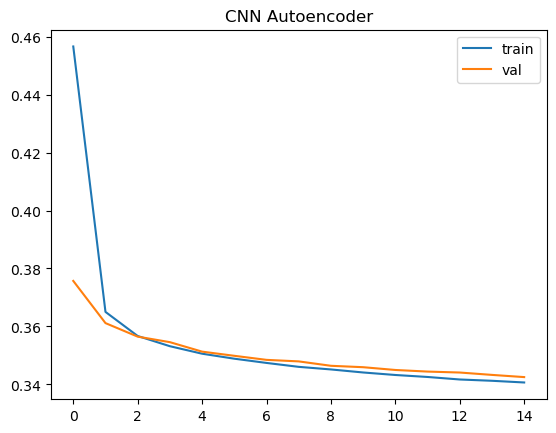

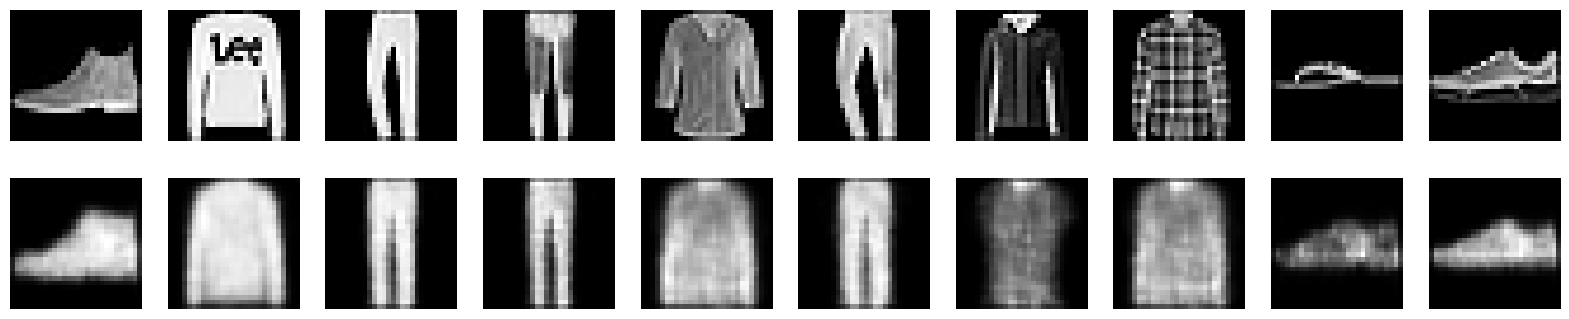

In [5]:
plt.plot(cnn_train_loss, label='train')
plt.plot(cnn_val_loss, label='val')
plt.title("CNN Autoencoder")
plt.legend()
plt.show()

show_reconstructions(model_cnn, test_loader)

In [6]:
# Сохранение весов обученных моделей
torch.save(model_fc.state_dict(), 'model_fc_weights.pth')
torch.save(model_cnn.state_dict(), 'model_cnn_weights.pth')
print("Веса моделей успешно сохранены!")

Веса моделей успешно сохранены!


In [ ]:
model_cnn.eval()
all_z = []
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        _, z = model_cnn(images)
        all_z.append(z.cpu().numpy())
z_test = np.concatenate(all_z, axis=0)
z1_min, z1_max = float(z_test[:, 0].min()), float(z_test[:, 0].max())
z2_min, z2_max = float(z_test[:, 1].min()), float(z_test[:, 1].max())

def plot_latent(z1, z2):
    latent = torch.tensor([[z1, z2]], dtype=torch.float32).to(device)

    with torch.no_grad():
        out = model_cnn.dec_fc(latent)
        out = out.view(-1, 16, 7, 7)
        decoded = model_cnn.dec_conv(out).cpu().numpy()[0]

    plt.figure(figsize=(4, 4))
    plt.imshow(decoded.squeeze(), cmap='gray')
    plt.axis('off')
    plt.show()

interactive_plot = interactive(
    plot_latent,
    z1=FloatSlider(min=z1_min, max=z1_max, step=0.01, value=(z1_min + z1_max)/2, description='z1'),
    z2=FloatSlider(min=z2_min, max=z2_max, step=0.01, value=(z2_min + z2_max)/2, description='z2'))

display(interactive_plot)

interactive(children=(FloatSlider(value=-5.69053316116333, description='z1', max=2.4790496826171875, min=-13.8…